## 1. Acquiring  the raw vector layers

we need three separate vector datasets for Kasarani:

- River centerline — we will pull the Nairobi River from OpenStreetMap (waterway=river tag) via the Overpass API, or use JRC Global Surface Water if we want a water-extent polygon instead of a line.
- Building footprints — Microsoft Building Footprints (Kenya coverage) or OSM buildings (building=*). MS footprints are usually more complete in informal settlements, which matters for our case.
- Study area boundary — a Kasarani ward/sub-county boundary, from OSM admin boundaries or Kenya's national spatial data portal, to clip everything to our area of interest.

In [79]:
import pandas as pd
import geopandas as gpd
import osmnx as ox

target_crs = "EPSG:32737"   # metric CRS for Kenya — used for all spatial ops

#### Step 1 — Study area boundary
- Pulled first because everything else gets clipped against it.
- osmnx geocodes the place name to its OSM administrative polygon.

In [80]:
aoi = ox.geocode_to_gdf("Kasarani, Nairobi, Kenya")
aoi_wgs84 = aoi.to_crs("EPSG:4326")   # keep a WGS84 copy — Earth Engine geometries need this
aoi = aoi.to_crs(target_crs)          # reproject immediately for all metric spatial ops
aoi.to_file("kasarani_aoi.gpkg", driver="GPKG")

#### Step 2 — River centerline
- Query OSM for the Nairobi River waterway, then reproject and clip it down to just the Kasarani AOI.

In [81]:
river = ox.features_from_place(
    "Kasarani, Nairobi, Kenya",
    tags={"waterway": "river"},
)
river = river[river.geometry.type.isin(["LineString", "MultiLineString"])]
river = river.to_crs(target_crs)
river = gpd.clip(river, aoi)
river.to_file("kasarani_river.gpkg", driver="GPKG")

In [82]:
import ee

# Initialize Earth Engine with the Google Cloud Project
ee.Initialize(project="causal-bus-404912")

# Load dataset
kenya_buildings = ee.FeatureCollection("projects/sat-io/open-datasets/MSBuildings/Kenya")

# Check if it loaded by printing the metadata/count
print("Dataset loaded successfully!")
print(kenya_buildings.limit(5).getInfo())

Dataset loaded successfully!
{'type': 'FeatureCollection', 'columns': {'FID': 'Long', 'system:index': 'String'}, 'version': 1653636443090994, 'id': 'projects/sat-io/open-datasets/MSBuildings/Kenya', 'properties': {'system:asset_size': 850253033}, 'features': [{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[33.87557666014897, 1.0723647648366932], [33.87559002779192, 1.0723112706616067], [33.875630215853334, 1.0723201619785412], [33.875621275714074, 1.0723736615384554], [33.87557666014897, 1.0723647648366932]]]}, 'id': '0000000000000000d951', 'properties': {'FID': 262144}}, {'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[34.17661062051326, 1.197215104867676], [34.17666408450745, 1.197161621687237], [34.1767086378117, 1.1972017538702415], [34.17665958674409, 1.1972552355409094], [34.17661062051326, 1.197215104867676]]]}, 'id': '0000000000000005023f', 'properties': {'FID': 327680}}, {'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates

In [83]:
folder = ee.data.listAssets("projects/sat-io/open-datasets/MSBuildings")
print(folder)   # lists every country asset in this collection

{'assets': [{'type': 'TABLE', 'name': 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/MSBuildings/Abyei', 'id': 'projects/sat-io/open-datasets/MSBuildings/Abyei', 'updateTime': '2022-05-27T07:26:51.088326Z'}, {'type': 'TABLE', 'name': 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/MSBuildings/Afghanistan', 'id': 'projects/sat-io/open-datasets/MSBuildings/Afghanistan', 'updateTime': '2022-05-27T07:26:51.450428Z'}, {'type': 'TABLE', 'name': 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/MSBuildings/Africa', 'id': 'projects/sat-io/open-datasets/MSBuildings/Africa', 'updateTime': '2022-05-27T07:26:51.836817Z'}, {'type': 'TABLE', 'name': 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/MSBuildings/Albania', 'id': 'projects/sat-io/open-datasets/MSBuildings/Albania', 'updateTime': '2022-05-27T07:26:52.124487Z'}, {'type': 'TABLE', 'name': 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/MSBuildings/Algeri

In [84]:
import geemap

# Filter to the real Kasarani AOI polygon (not a rough bounding box), on Earth
# Engine's servers — the full Kenya dataset never has to be downloaded locally.
kasarani_geom = geemap.geopandas_to_ee(aoi_wgs84)
kasarani_buildings = kenya_buildings.filterBounds(kasarani_geom)
print("Building count in AOI:", kasarani_buildings.size().getInfo())

Building count in AOI: 57422


In [85]:
task = ee.batch.Export.table.toDrive(
    collection=kasarani_buildings,
    description="kasarani_buildings_export",
    fileFormat="GeoJSON",
)
task.start()

# GEE exports run asynchronously — the file does not exist yet.
import time
while task.active():
    print("Export running...", task.status()["state"])
    time.sleep(15)
print("Export finished:", task.status()["state"])

Export running... READY
Export running... RUNNING
Export finished: COMPLETED


#### Step 3 — Building footprints

In [86]:
buildings = gpd.read_file("kasarani_buildings_export.geojson")
buildings = buildings.to_crs(target_crs)
buildings = gpd.clip(buildings, aoi)

## 2. Validate and repair geometries

- Real-world vector data has broken geometries — self-intersecting polygons, duplicate points, empty geometries from failed exports.

In [87]:
from shapely.validation import make_valid

# drop null/empty geometries
buildings = buildings[~buildings.geometry.is_empty & buildings.geometry.notna()]

# fix invalid polygons (self-intersections etc.)
buildings["geometry"] = buildings.geometry.apply(
    lambda g: make_valid(g) if not g.is_valid else g
)

# explode multipart geometries into single parts (a MultiPolygon building
# footprint becomes multiple rows — usually what you want for counting)
buildings = buildings.explode(index_parts=False).reset_index(drop=True)

## 3. Remove duplicates and slivers

Overlapping exports (e.g. combining OSM + MS footprints) create duplicate or near-duplicate polygons, and clipping operations can leave tiny sliver polygons.

In [88]:
buildings = buildings.drop_duplicates(subset="geometry")

# drop slivers below a minimum area threshold (e.g. 4 m² — too small to be a real structure)
buildings = buildings[buildings.geometry.area > 4]

## 4. Clean attributes

In [89]:
# standardize column names/types, drop columns not needed
buildings = buildings.rename(columns=str.lower)
buildings["building_type"] = buildings.get("building", pd.Series(dtype="object")).fillna("unknown")

## 5. Generate the buffer zone and label encroachment

In [90]:
from shapely.geometry import Point, LineString, Polygon

# buffer the river line by 30m — per the revised proposal's riparian reserve
river_union = river.geometry.union_all()
riparian_buffer = river_union.buffer(30)

## 6. Spatial Indexing & Metric Overlay

In [91]:
# Build spatial index using your variable name
spatial_index = buildings.sindex

# Calculate exact distances and exact encroached area
buildings['dist_to_river_m'] = buildings.geometry.distance(river_union)
buildings['inside_buffer'] = buildings.geometry.intersects(riparian_buffer)

# Exact topological intersection for area calculation
intersections = buildings.geometry.intersection(riparian_buffer)
buildings['encroached_area_m2'] = intersections.area
buildings['total_area_m2'] = buildings.geometry.area
buildings['pct_encroached'] = (buildings['encroached_area_m2'] / buildings['total_area_m2']) * 100

# Risk classification tier
def classify_risk(dist):
    if dist <= 10.0:
        return 'High Risk (<10m)'
    elif 10.0 < dist <= 20.0:
        return 'Medium Risk (10m-20m)'
    elif 20.0 < dist <= 30.0:
        return 'Low Risk (20m-30m)'
    else:
        return 'Safe Zone (>30m)'

buildings['risk_category'] = buildings['dist_to_river_m'].apply(classify_risk)

## 7. Raster Intergration (Sentinel-2 Tile)

In [92]:
# Using ee (Google Earth Engine) to export a Sentinel-2 GeoTIFF
import ee

ee.Initialize(project="causal-bus-404912")

# Reuse the same AOI as the buildings/river layers, rather than a separately
# typed bounding box, so the imagery tile actually aligns with them
kasarani_bbox = ee.Geometry.Rectangle(list(aoi_wgs84.total_bounds))

# Load Sentinel-2 SR collection and filter low cloud cover
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(kasarani_bbox)
    .filterDate("2024-01-01", "2024-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
    .median()
    .clip(kasarani_bbox)
)

# Select RGB bands (B4, B3, B2) or NIR (B8)
rgb_image = s2.select(["B4", "B3", "B2"])

**Before exporting:** preview the tile first. A full export can take
several minutes — checking a thumbnail catches a wrong AOI or a cloud-heavy
composite before that time is spent.

In [93]:
thumb_url = rgb_image.getThumbURL({
    "region": kasarani_bbox,
    "dimensions": 512,
    "min": 0, "max": 3000,
    "bands": ["B4", "B3", "B2"],
})
print("Preview this tile before exporting:", thumb_url)

Preview this tile before exporting: https://earthengine.googleapis.com/v1/projects/causal-bus-404912/thumbnails/4d50946fb64d5274195b08c3f612be5e-cbc610413af5fb011f918bf992ffce70:getPixels


In [94]:
# Export directly to the Google Drive
task = ee.batch.Export.image.toDrive(
    image=rgb_image,
    description="kasarani_sentinel_tile",
    folder="EarthEngine",
    fileNamePrefix="kasarani_sentinel_tile",
    region=kasarani_bbox,
    scale=10,  # 10m spatial resolution
    crs="EPSG:32737",
)
task.start()

# Image exports run asynchronously too
import time
while task.active():
    print("Export running...", task.status()["state"])
    time.sleep(15)
print("Export finished:", task.status()["state"])

Export running... READY
Export running... RUNNING
Export running... RUNNING
Export running... RUNNING
Export running... RUNNING
Export running... RUNNING
Export finished: COMPLETED


In [95]:
from rasterio.transform import from_origin
import rasterio
import numpy as np
import os

raster_filename = "kasarani_sentinel_tile.tif"

# Read satellite imagery tile metadata
with rasterio.open(raster_filename) as src:
    raster_bounds = src.bounds
    raster_crs = src.crs

### Confirm the tile is correct

Before building anything on top of this raster: check that its bounds
actually overlap the study area, and that it isn't mostly cloud/nodata gaps
left over from the median composite.

In [96]:
print("Raster CRS:", raster_crs)
print("Raster bounds:", raster_bounds)
print("AOI bounds (same CRS):", aoi.to_crs(raster_crs).total_bounds)
# these two bound sets should overlap closely — if not, this is the wrong
# tile, or a CRS mismatch happened somewhere upstream

with rasterio.open(raster_filename) as src:
    arr = src.read(1)
    nodata_fraction = (np.isnan(arr) | (arr == 0)).mean()
    print(f"Zero/NaN pixel fraction: {nodata_fraction:.2%}")
    # a high fraction here usually means the cloud filter/date range left
    # gaps the median composite couldn't fill — consider widening the date
    # range or loosening the cloud threshold if this is high

Raster CRS: EPSG:32737
Raster bounds: BoundingBox(left=258720.0, bottom=9860140.0, right=278250.0, top=9871640.0)
AOI bounds (same CRS): [ 258733.64555564 9860152.03893585  278241.90102304 9871623.41708491]
Zero/NaN pixel fraction: 0.27%


## 8. Summary Metrics and Export

In [97]:
import os
import pyogrio

output_file = "kasarani_encroachment_results.gpkg"

# Start with a clean GeoPackage
if os.path.exists(output_file):
    os.remove(output_file)

# Clean buildings GeoDataFrame

buildings_export = buildings.copy()

# Drop conflicting index/fid columns
if "fid" in buildings_export.columns:
    buildings_export = buildings_export.drop(columns=["fid"])

buildings_export = buildings_export.reset_index(drop=True)

# Fix invalid geometries and explode MultiPolygons to force single Polygon types
buildings_export["geometry"] = buildings_export.geometry.buffer(0)
buildings_export = buildings_export.explode(index_parts=False).reset_index(
    drop=True
)

# 2. Clean buffer GeoDataFrame
buffer_export = gpd.GeoDataFrame(geometry=[riparian_buffer], crs=target_crs)

if "fid" in buffer_export.columns:
    buffer_export = buffer_export.drop(columns=["fid"])

buffer_export = buffer_export.reset_index(drop=True)
buffer_export["geometry"] = buffer_export.geometry.buffer(0)
buffer_export = buffer_export.explode(index_parts=False).reset_index(drop=True)


# 3. Write layers using pyogrio

# First layer: creates the file (append=False)
pyogrio.write_dataframe(
    buildings_export,
    output_file,
    layer="buildings_classified",
    driver="GPKG",
    append=False,
)

# Second layer: appends to existing GeoPackage (append=True)
pyogrio.write_dataframe(
    buffer_export,
    output_file,
    layer="riparian_buffer",
    driver="GPKG",
    append=True,
)

## 9.Visualization overview of the data

### a) Vector Enchroachment Map
- Overlays the Kasarani boundary, the riparian buffer zone, and highlights encroaching buildings vs. safe buildings.

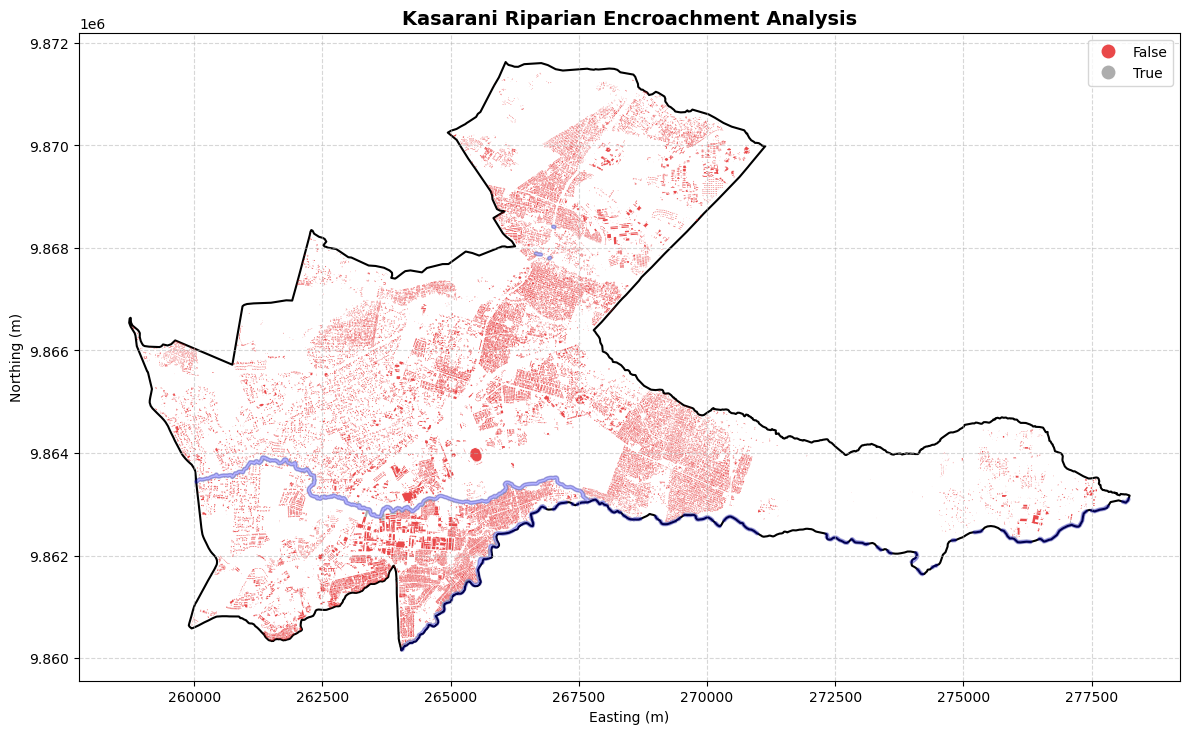

In [98]:
import matplotlib.pyplot as plt

# Create plot canvas
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot Study Area Boundary
aoi.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, label="AOI")

# 2. Plot Riparian Buffer
buffer_export.plot(
    ax=ax, color="blue", alpha=0.3, edgecolor="navy", label="30m Riparian Buffer"
)

# 3. Plot Buildings (Color-coded by Encroachment Status)
if "inside_buffer" in buildings_export.columns:
    buildings_export.plot(
        ax=ax,
        column="inside_buffer",
        cmap="Set1",
        categorical=True,
        legend=True,
        markersize=10,
        alpha=0.8,
    )
else:
    buildings_export.plot(
        ax=ax, color="red", markersize=8, alpha=0.7, label="Buildings"
    )

plt.title(
    "Kasarani Riparian Encroachment Analysis", fontsize=14, fontweight="bold"
)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("kasarani_encroachment_map.png", dpi=300)
plt.show()

### b) Raster Overlay Map (Sentinel-2 RGB + Vector Layers)
- Plots the 10m Sentinel-2 satellite tile in the background
and overlays the spatial layers on top.

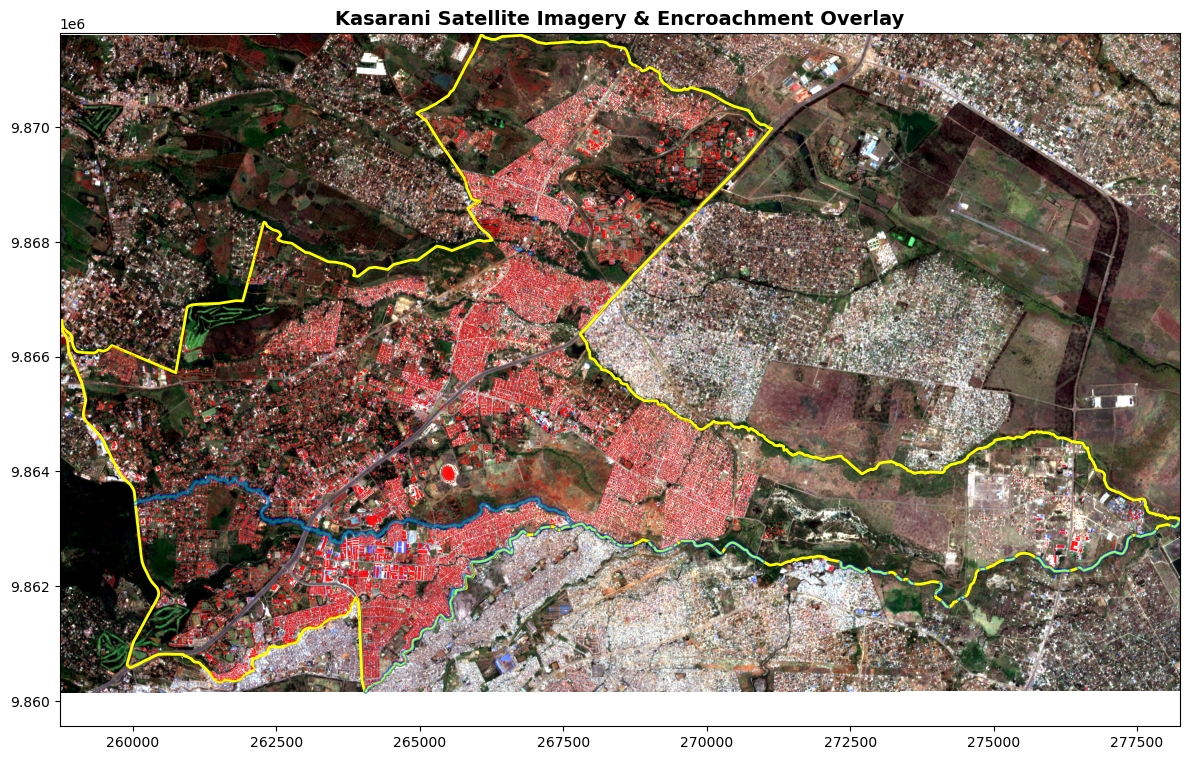

In [99]:
from rasterio.plot import show

# Open local Sentinel-2 GeoTIFF
with rasterio.open(raster_filename) as src:
    fig, ax = plt.subplots(figsize=(12, 10))

    # 1. Plot Sentinel-2 RGB Image (Normalize bands B4, B3, B2 for display)
    # Brightness adjustment using percentile clipping
    rgb_data = src.read([1, 2, 3]).astype(float)

    rgb_scaled = np.zeros_like(rgb_data)
    for i in range(3):
        band = rgb_data[i]
        p2, p98 = np.nanpercentile(band, (2, 98))
        rgb_scaled[i] = np.clip((band - p2) / (p98 - p2), 0, 1)

    show(rgb_scaled, transform=src.transform, ax=ax)

    # 2. Overlay Vector Layers on Top
    aoi.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=2)
    buffer_export.plot(
        ax=ax, facecolor="cyan", alpha=0.4, edgecolor="blue", linewidth=1
    )
    buildings_export.plot(ax=ax, color="red", markersize=6, alpha=0.9)

    plt.title(
        "Kasarani Satellite Imagery & Encroachment Overlay",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("kasarani_raster_overlay.png", dpi=300)
    plt.show()